# Models
two simple, poor-performing models to try and do something with the data. not everything i've put here will fit in the body, but i do think moving the rest to the appendix (specific tuning plots/code, etc.) would be useful
## Data
This is where the data stood at the time based on how i interpreted eda, idk if this is still where we are but i needed something and this was something. when merging can just use whatever we end up with there.

In [4]:
# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Learning Libraries
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler # scaling features
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import plot_tree
from sklearn import metrics

# the warnings are too much for me
import warnings
warnings.filterwarnings('ignore')

DATA_FOLDER: str = "./data/"
UNICEF_DATA_CSV: str = DATA_FOLDER + "unicef_malawi.csv"

malawi = pd.read_csv(UNICEF_DATA_CSV)

# depression_map maps values in FCF26 to binary; where 0 = not depressed, and 1 = depressed.
depression_map: dict[str: int] = {
    "NEVER": 0,
    "A FEW TIMES A YEAR": 0,
    "MONTHLY": 1,
    "WEEKLY": 1,
    "DAILY": 1,
}
malawi["FCF26_binary"] = malawi["FCF26"].map(depression_map)

# drop rows where target empty
malawi = malawi[malawi["FCF26_binary"].notna()]

# these are the features retained in that one notebook cell in eda_draft
mask = ['HH1',
 'CL3',
 'LS2',
 'LS1',
 'WS4',
 'LS3',
 'HH7',
 'VT22B',
 'MA2',
 'HC4',
 'VT22A',
 'CL13',
 'LS4',
 'WS11',
 'VT22C',
 'HH2',
 'WS7',
 'HC12',
 'MSTATUS',
 'FCD2H',
 'WS1',
 'FCD2J',
 'VT20',
 'HC5',
 'HC8',
 'VT22D',
 'WB4']

# so we filter the data to that and normalize the entries
malawi = malawi[mask + ["FCF26_binary"]].copy()
malawi = malawi.apply(lambda col: col.map(lambda x: x.strip().upper() if isinstance(x, str) else x))
# convert missing-like value to missing
malawi = malawi.replace({
    r"NO RESPONSE.*": pd.NA,
    r"^DK.*": pd.NA,
}, regex=True)

# safety, happiness, and life improvement are likert-esque questions; thus can be converted to cardinal values
safety_map: dict[str: int] = {
	"NEVER WALK ALONE AFTER DARK": 0,
	"VERY UNSAFE": 1,
	"UNSAFE": 2,
	"SAFE": 3,
	"VERY SAFE": 4

}

happiness_map = {
	"VERY UNHAPPY": 0,
	"SOMEWHAT UNHAPPY": 1,
	"NEITHER HAPPY NOR UNHAPPY": 2,
	"SOMEWHAT HAPPY": 3,
	"VERY HAPPY": 4
}

improvement_map = {
	"WORSENED": -1,
	"WORSE": -1,
	"MORE OR LESS THE SAME": 0,
	"BETTER": 1,
	"IMPROVED": 1
}
# water sufficiency and yes/no questions are binary-like in answer so map to binary
sufficiency_map = {
    "YES, AT LEAST ONCE": 1,
    "NO, ALWAYS SUFFICIENT": 0
}

yn_map = {
    "YES": 1,
    "NO": 0
}

# apply conversions from above to relevant features
malawi["WS7"] = malawi["WS7"].replace(sufficiency_map)
malawi["LS1"] = malawi["LS1"].replace(happiness_map)
malawi["LS3"] = malawi["LS3"].replace(improvement_map)
malawi["LS4"] = malawi["LS4"].replace(improvement_map)
malawi["VT20"] = malawi["VT20"].replace(safety_map)
malawi = malawi.replace(yn_map)

# one-hot remaining features where conversion is more difficult
categorical_cols = ["HH7", "MSTATUS", "HC4", "HC5", "HC8", "WS1", "WS11"]
malawi = pd.get_dummies(malawi, columns=categorical_cols, dummy_na=True)

malawi["ws4_na"] = malawi["WS4"].str.contains("MEMBERS DO NOT COLLECT", na=False).astype(int)
malawi["WS4"] = pd.to_numeric(malawi["WS4"], errors="coerce")

# set nans to a unique value to consider missingness as potential indicators
for col in malawi.columns:
    if malawi[col].isna().any():
        malawi[col + "_missing"] = malawi[col].isna().astype(int)
        malawi[col] = malawi[col].fillna(-999)

# Feature matrix and response vector
X, y = malawi.drop(["FCF26_binary"], axis=1), malawi["FCF26_binary"]

# Stratify split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle= True, test_size = 0.2, random_state=42)


## Classification Tree and Bagging
Tried this b/c interpretable. Bagging didn't balance the data the way i wanted so there's also that to work on. 

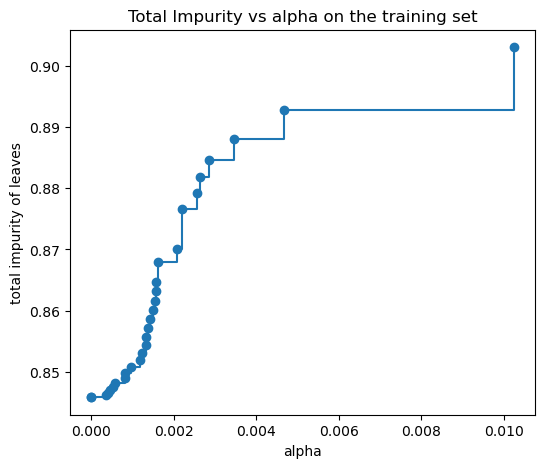

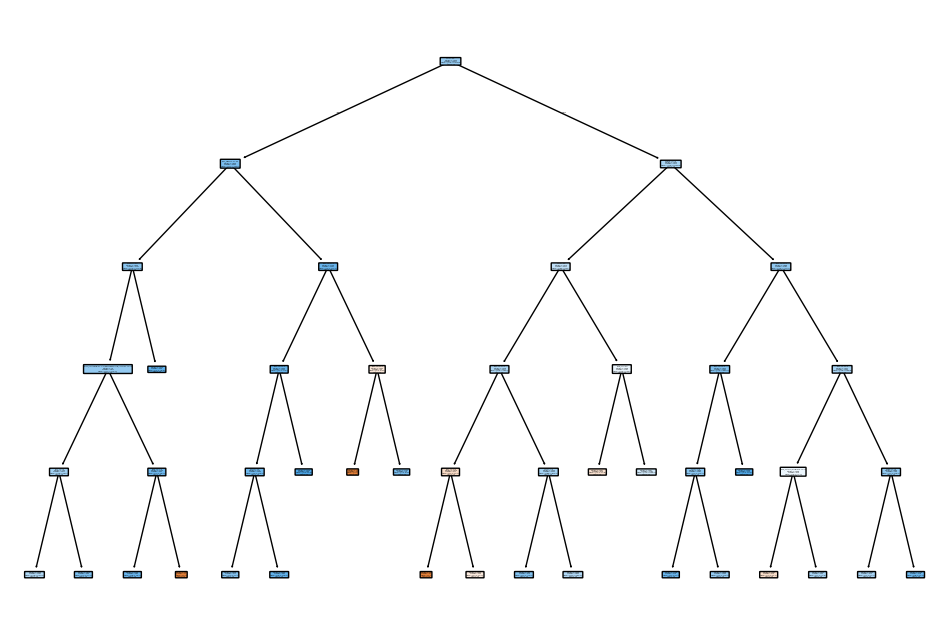

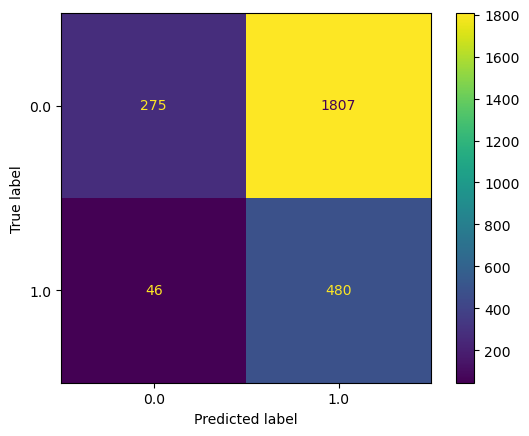

Accuracy: 0.28949386503067487
Precision: 0.20988194140795802
Sensitivity/Recall: 0.9125475285171103
Specificity: 0.13208453410182516
F Score: 0.3412726626377533


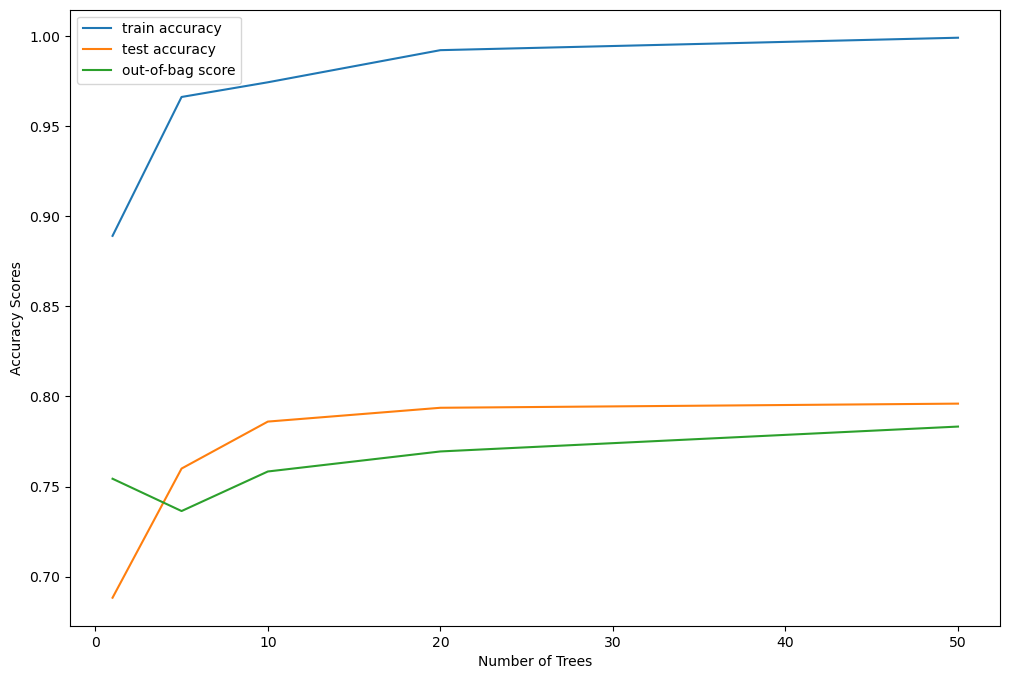

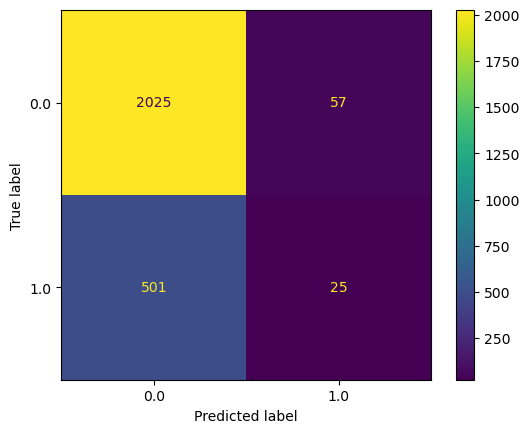

Accuracy: 0.786042944785276
Precision: 0.3048780487804878
Sensitivity/Recall: 0.04752851711026616
Specificity: 0.9726224783861671
F Score: 0.08223684210526316


In [4]:
# Cost complexity pruning
tree_clf = DecisionTreeClassifier(class_weight={0:1, 1:7.86}, max_depth=5, criterion="entropy")
tree_clf.fit(X_train, y_train)
path = tree_clf.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# plot cost complexity
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(ccp_alphas, impurities, marker="o", drawstyle="steps-post")
ax.set_xlabel("alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs alpha on the training set")
plt.show()

# train tree with complexity found
clf = DecisionTreeClassifier(ccp_alpha= 0.001, class_weight={0:1, 1:7.86}, max_depth = 5, criterion="entropy")
clf.fit(X_train, y_train)

# plot tree
plt.figure(figsize=(12,8))
plot_tree(clf, rounded = True, filled = True, feature_names=X_train.columns, class_names = [str(c) for c in clf.classes_])
plt.show()

# predict test values from trained tree
y_pred = clf.predict(X_test)

# plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)
plt.show()
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")
print(f"Sensitivity/Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Specificity: {metrics.recall_score(y_test, y_pred, pos_label=0.0)}")
print(f"F Score: {metrics.f1_score(y_test, y_pred)}")

# i'll try bagging, that's a good trick
n_est = np.array([1,5,10,20,50],dtype=int)

bags = []

for n in n_est:
	bag_clf = BaggingClassifier(
		estimator=DecisionTreeClassifier(class_weight={0:1, 1:7.86},criterion="entropy"),
		n_estimators=n,
		bootstrap=True,
		random_state=42,
		oob_score=True
	)

	bag_clf.fit(X_train, y_train)

	bags.append(bag_clf)

tracc = np.array([b.score(X_train, y_train) for b in bags])
tacc = np.array([b.score(X_test, y_test) for b in bags])
oobs = np.array([b.oob_score_ for b in bags])

plt.figure(figsize=(12, 8))
plt.plot(n_est, tracc, label = "train accuracy")
plt.plot(n_est, tacc, label = "test accuracy")
plt.plot(n_est, oobs, label = "out-of-bag score")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy Scores")
plt.legend()
plt.show()

# Code for your answer here
bag_clf = BaggingClassifier(
	estimator=DecisionTreeClassifier(class_weight={0:1, 1:7.86},criterion="entropy"),
	n_estimators=10,
	bootstrap=True,
	random_state=42
)

bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)
ConfusionMatrixDisplay.from_estimator(bag_clf, X_test, y_test)
plt.show()

print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")
print(f"Sensitivity/Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Specificity: {metrics.recall_score(y_test, y_pred, pos_label=0.0)}")
print(f"F Score: {metrics.f1_score(y_test, y_pred)}")

## Logistic Regression
That didn't work well so i tried this b/c it is also somewhat interpretable. Used Recall for tuning b/c false negatives are most consequential negative outcomes and tried both the weights from one of the eda files and "balanced". ripped coefficient function from workshops. this thing takes forever to run b/c of the cv, so can also tune that a bit probs.

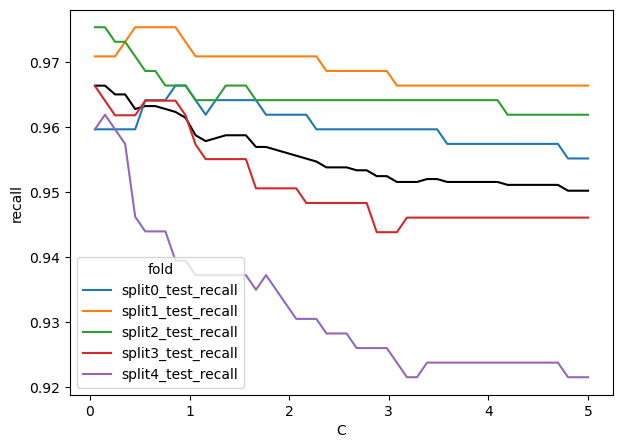

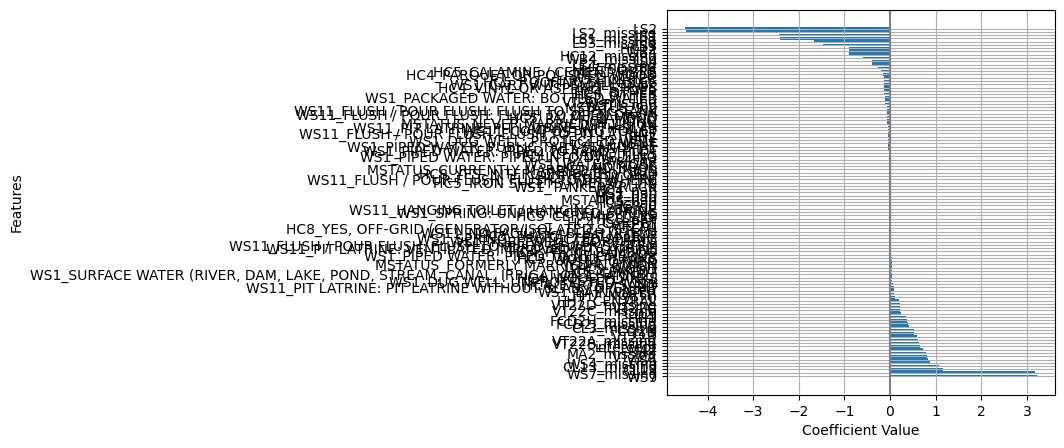

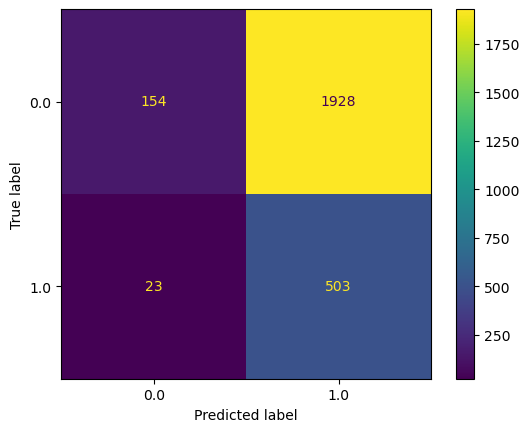

Accuracy: 0.25191717791411045
Precision: 0.20691073632250104
Sensitivity/Recall: 0.9562737642585551
Specificity: 0.07396733909702209
F Score: 0.3402096719648292


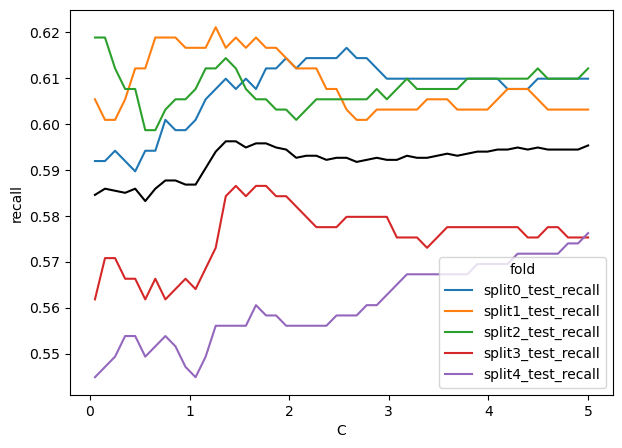

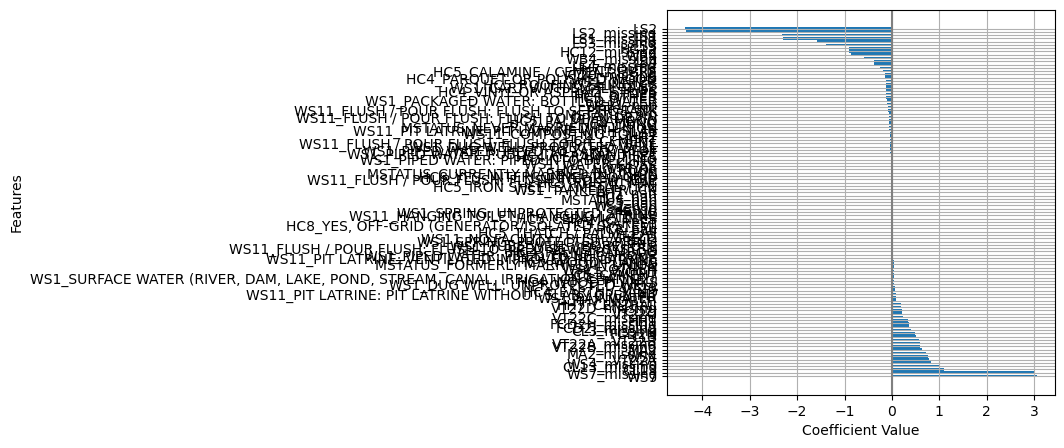

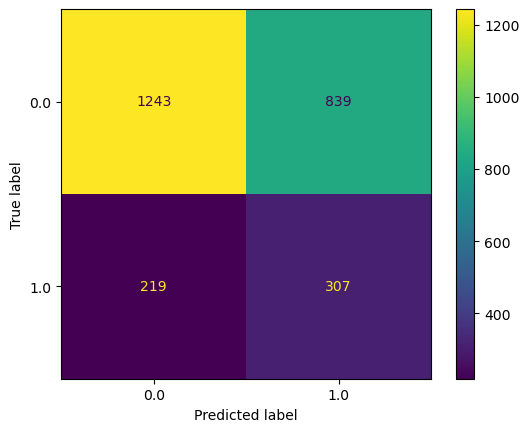

Accuracy: 0.5943251533742331
Precision: 0.26788830715532286
Sensitivity/Recall: 0.5836501901140685
Specificity: 0.5970220941402498
F Score: 0.3672248803827751


In [5]:
def get_coefs(m, plot = False, feature_names = None, figsize = (5,5), figtitle = None, intercept = True):
    """Returns model coefficients in a data frame for a fitted linear model.
    
    Args:
        m: sklearn linear model object or pipeline with linear model as final step
        plot: boolean value, should coefficients be plotted with error bars
        feature_names: list of feature names to use in the plot 
        figsize: tuple defining figure size
        figtitle: string defining figure title
        intercept: boolean value, should intercept be included in the plot
    """
    
    # Extract intercept and coefficients into a single array
    w0 = m[-1].intercept_ if isinstance(m, sklearn.pipeline.Pipeline) else m.intercept_
    w1 = m[-1].coef_ if isinstance(m, sklearn.pipeline.Pipeline) else m.coef_
    w = np.concatenate((w0.reshape(-1), w1.reshape(-1)))
    # Extract name of features
    if feature_names is None:
        feature_names = m[:-1].get_feature_names_out() if isinstance(m, sklearn.pipeline.Pipeline) else m.feature_names_in_
    feature_names = np.concatenate((['intercept'], feature_names))
    # Create a data frame
    w_df = pd.DataFrame({'feature': feature_names, 'coef': w}).sort_values ("coef", ascending=False)

    if plot:
        if not intercept:
            w_df = w_df[w_df['feature'] != 'intercept']
        plt.figure(figsize=figsize)
        plt.barh(w_df['feature'], w_df['coef'])
        plt.ylabel('Features')
        plt.xlabel('Coefficient Value')
        plt.axvline(x=0, color=".5")
        if figtitle is not None:
            plt.title(figtitle)
        plt.grid()
        plt.show()
    
    return  w_df

# Pipeline 
log_pipe_l2 = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight={0:1, 1:7.86}, random_state=42, penalty='l2', solver='liblinear',
        max_iter=1000)
)

# Possible C values: 
C_list = np.linspace(-5,5, num=100)

# Grid search CV:
log_rs = GridSearchCV(log_pipe_l2, 
                      param_grid={'logisticregression__C': C_list},
                      scoring = ["accuracy", "f1","recall","precision"], #Evaluation metrics to compute on validation sets
                      cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                      refit = "recall", # Refits the best model on the entire dataset using the accuracy metric 
                      return_train_score = True)

# Tune the model with grid search:
log_rs.fit(X_train, y_train)

# Extract only mean and split scores
cv_accuracy = pd.DataFrame(
    data = log_rs.cv_results_
).filter(
    # Extract the split#_test_f1 and mean_test_f1 columns
    regex = '(split[0-4]+|mean)_test_recall'
).assign(
    # Add the alphas as a column
    C = C_list
)
# Reshape the data frame for plotting
d = cv_accuracy.melt(
    id_vars=('C','mean_test_recall'),
    var_name='fold',
    value_name='recall'
)
# Plot the validation scores across folds
plt.figure(figsize=(7,5))
sns.lineplot(x='C', y='recall', color='black', errorbar=None, data = d)  # Plot the mean score in black.
sns.lineplot(x='C', y='recall', hue='fold', data = d) # Plot the curves for each fold in different colors
plt.show()

log_pipe_l2 = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight={0:1, 1:7.86}, random_state=42, penalty='l2', solver='liblinear',
        max_iter=1000, C=.75)
)

log_pipe_l2.fit(X_train, y_train)
get_coefs(log_pipe_l2, plot=True)
y_pred = log_pipe_l2.predict(X_test)
ConfusionMatrixDisplay.from_estimator(log_pipe_l2, X_test, y_test)
plt.show()
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")
print(f"Sensitivity/Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Specificity: {metrics.recall_score(y_test, y_pred, pos_label=0.0)}")
print(f"F Score: {metrics.f1_score(y_test, y_pred)}")

log_pipe_bal = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight="balanced", random_state=42, penalty='l2', solver='liblinear',
        max_iter=1000)
)

# Grid search CV:
log_rs = GridSearchCV(log_pipe_bal, 
                      param_grid={'logisticregression__C': C_list},
                      scoring = ["accuracy", "f1","recall","precision"], #Evaluation metrics to compute on validation sets
                      cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                      refit = "recall", # Refits the best model on the entire dataset using the accuracy metric 
                      return_train_score = True)

# Tune the model with grid search:
log_rs.fit(X_train, y_train)

# Extract only mean and split scores
cv_accuracy = pd.DataFrame(
    data = log_rs.cv_results_
).filter(
    # Extract the split#_test_f1 and mean_test_f1 columns
    regex = '(split[0-4]+|mean)_test_recall'
).assign(
    # Add the alphas as a column
    C = C_list
)
# Reshape the data frame for plotting
d = cv_accuracy.melt(
    id_vars=('C','mean_test_recall'),
    var_name='fold',
    value_name='recall'
)
# Plot the validation scores across folds
plt.figure(figsize=(7,5))
sns.lineplot(x='C', y='recall', color='black', errorbar=None, data = d)  # Plot the mean score in black.
sns.lineplot(x='C', y='recall', hue='fold', data = d) # Plot the curves for each fold in different colors
plt.show()

log_pipe_bal = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight="balanced", random_state=42, penalty='l2', solver='liblinear',
        max_iter=1000, C=1.5)
)

log_pipe_bal.fit(X_train, y_train)
get_coefs(log_pipe_bal, plot=True)
y_pred = log_pipe_bal.predict(X_test)
ConfusionMatrixDisplay.from_estimator(log_pipe_bal, X_test, y_test)
plt.show()

print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")
print(f"Sensitivity/Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Specificity: {metrics.recall_score(y_test, y_pred, pos_label=0.0)}")
print(f"F Score: {metrics.f1_score(y_test, y_pred)}")

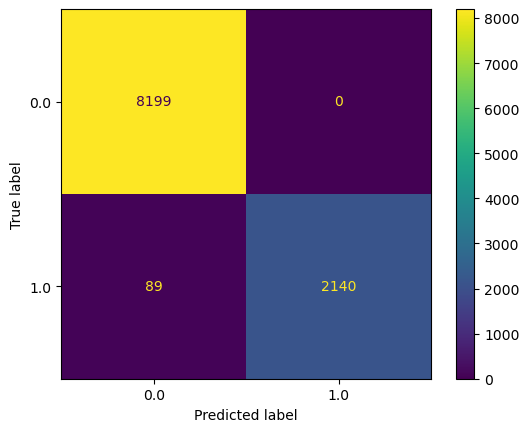

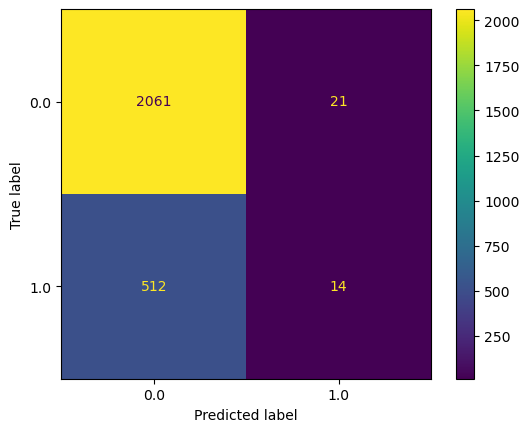

Accuracy: 0.7956288343558282
Precision: 0.4
Sensitivity/Recall: 0.026615969581749048
Specificity: 0.9899135446685879
F Score: 0.049910873440285206


In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(class_weight={0:1, 1:7.86}, random_state=42, n_estimators=20)
rf_clf.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(rf_clf, X_train, y_train)
plt.show()

y_pred = rf_clf.predict(X_test)
ConfusionMatrixDisplay.from_estimator(rf_clf, X_test, y_test)
plt.show()

print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")
print(f"Sensitivity/Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Specificity: {metrics.recall_score(y_test, y_pred, pos_label=0.0)}")
print(f"F Score: {metrics.f1_score(y_test, y_pred)}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
0.4182711789682464


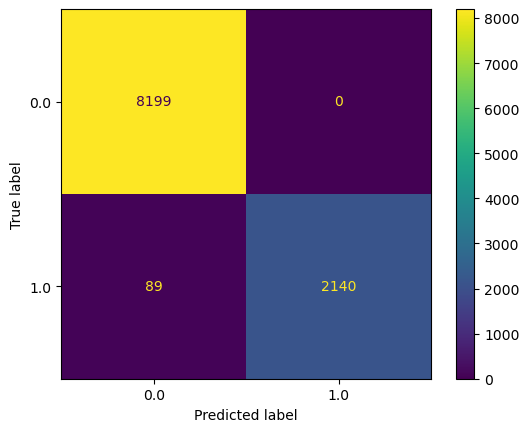

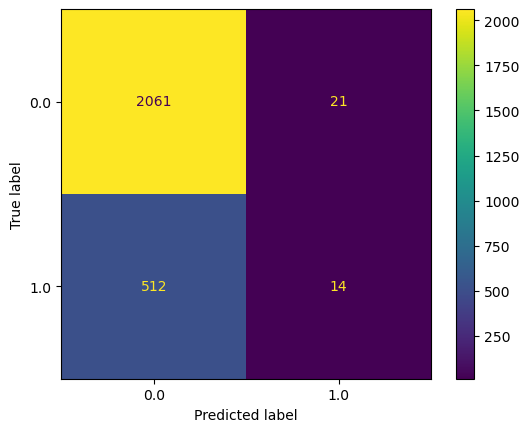

Accuracy: 0.7956288343558282
Precision: 0.4
Sensitivity/Recall: 0.026615969581749048
Specificity: 0.9899135446685879
F Score: 0.049910873440285206


In [8]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_features': ['sqrt'],
    'min_samples_leaf': [5, 10, 20, 50],
    'max_depth': [None]
}

rf = RandomForestClassifier(class_weight={0: 1, 1: 7.86}, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=cv,
    scoring='f1',       
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

ConfusionMatrixDisplay.from_estimator(rf_clf, X_train, y_train)
plt.show()

y_pred = rf_clf.predict(X_test)
ConfusionMatrixDisplay.from_estimator(rf_clf, X_test, y_test)
plt.show()
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")
print(f"Sensitivity/Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Specificity: {metrics.recall_score(y_test, y_pred, pos_label=0.0)}")
print(f"F Score: {metrics.f1_score(y_test, y_pred)}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 106)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        13,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,017 (86.00 KB)

 Trainable params: 22,017 (86.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2803 - auc: 0.5646 - loss: 1.6006 - val_accuracy: 0.2349 - val_auc: 0.5936 - val_loss: 0.9352
Epoch 2/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2566 - auc: 0.5926 - loss: 1.5380 - val_accuracy: 0.2253 - val_auc: 0.5859 - val_loss: 0.9578
Epoch 3/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2604 - auc: 0.6091 - loss: 1.5161 - val_accuracy: 0.2196 - val_auc: 0.6000 - val_loss: 0.9435
Epoch 4/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2664 - auc: 0.6351 - loss: 1.4885 - val_accuracy: 0.2359 - val_auc: 0.5913 - val_loss: 0.9223
Epoch 5/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2741 - auc: 0.6367 - loss: 1.4868 - val_accuracy: 0.2234 - val_auc: 0.5879 - val_loss: 0.9544
Epoch 6/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2602 - auc: 0.6398 - loss: 1.4819 - val_accuracy: 0.2272 - val_auc: 0.5867 - val_loss: 0.9085
Epoch 7/100
294/294 ━━━━━━━━━━━━━━

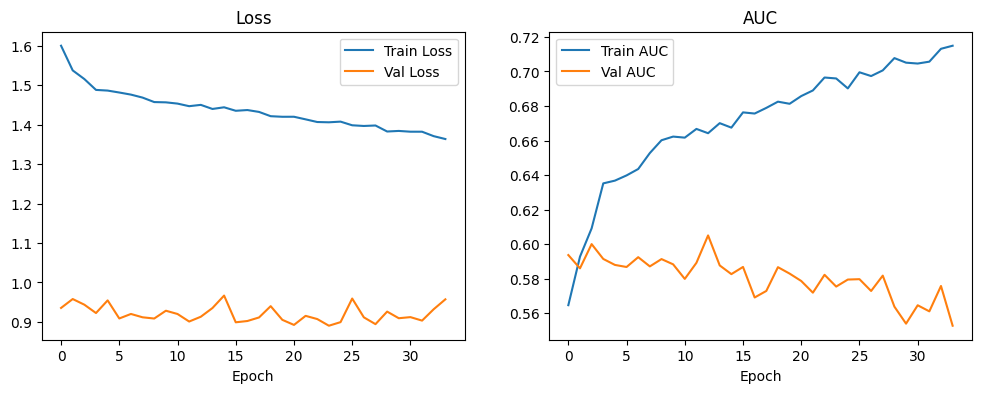

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Accuracy: 0.3309049079754601
Precision: 0.21585081585081586
Sensitivity/Recall: 0.8802281368821293
Specificity: 0.19212295869356388
F Score: 0.3466866342193935


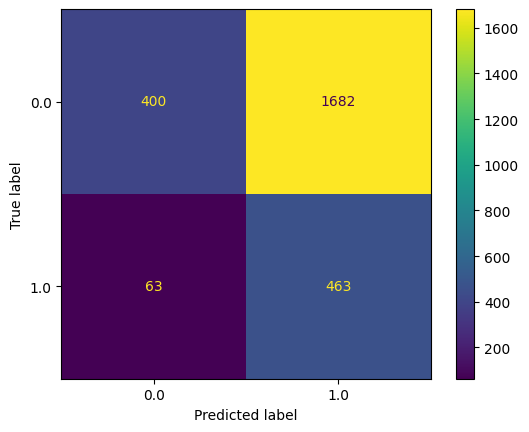

In [ ]:
import keras
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import numpy as np

# Scale features (important for NNs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Class weights
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict = {0: 1, 1: 7.86}

# Build model - following your week 9 style
D = X_train_scaled.shape[1]

input_layer = keras.Input(shape=(D,))
h1 = keras.layers.Dense(128, activation='relu')(input_layer)
h1 = keras.layers.Dropout(0.3)(h1)
h2 = keras.layers.Dense(64, activation='relu')(h1)
h2 = keras.layers.Dropout(0.2)(h2)
output_layer = keras.layers.Dense(1, activation='sigmoid')(h2)

model_nn = keras.Model(inputs=input_layer, outputs=output_layer)

model_nn.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.AUC(name='auc'),
    ],
)

model_nn.summary()

# Early stopping - from week 10
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    mode='min',
    patience=10,
    restore_best_weights=True
)

history = model_nn.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

# Plot training history - from week 9 style
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Val Loss')
ax[0].set_title('Loss')
ax[0].set_xlabel('Epoch')
ax[0].legend()
ax[1].plot(history.history['auc'], label='Train AUC')
ax[1].plot(history.history['val_auc'], label='Val AUC')
ax[1].set_title('AUC')
ax[1].set_xlabel('Epoch')
ax[1].legend()
plt.show()

# Predict
y_prob = model_nn.predict(X_test_scaled)
y_pred = (y_prob >= 0.5).astype(int)

print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Precision: {metrics.precision_score(y_test, y_pred)}")
print(f"Sensitivity/Recall: {metrics.recall_score(y_test, y_pred)}")
print(f"Specificity: {metrics.recall_score(y_test, y_pred, pos_label=0.0)}")
print(f"F Score: {metrics.f1_score(y_test, y_pred)}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [6]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.86      0.19      0.31      2082
         1.0       0.22      0.88      0.35       526

    accuracy                           0.33      2608
   macro avg       0.54      0.54      0.33      2608
weighted avg       0.73      0.33      0.32      2608

